In [1]:
%load_ext autoreload
%autoreload 2

In [38]:
! pip install -r requirements.txt

In [4]:
import pandas as pd
data = pd.read_csv('data/knot_data.csv')
data2 = pd.read_csv('data/knot_data2.csv')
data3 = pd.read_csv('data/knot_data3.csv')
merged_data = pd.merge(pd.merge(data, data2, on='Name'), data3, on='Name')
merged_data.to_csv('data/knot_data_merged.csv', index=False)

In [21]:
from data_parsers import parse_pd_notation, parse_volume, parse_list_of_features

parse_pd_notation('[[1;5;2;4];[3;1;4;6];[5;3;6;2]]')

['1', '5', '2', '4']
['3', '1', '4', '6']
['5', '3', '6', '2']


[[1, 5, 2, 4], [3, 1, 4, 6], [5, 3, 6, 2]]

In [22]:
volumes = parse_list_of_features(list(merged_data["Volume"]), parse_volume)

In [25]:
pd_notations = parse_list_of_features(list(merged_data["PD Notation"]), parse_pd_notation)

parsing pd notation: [[1;5;2;4];[3;1;4;6];[5;3;6;2]]
parsing pd notation: [[4;2;5;1];[8;6;1;5];[6;3;7;4];[2;7;3;8]]
parsing pd notation: [[2;8;3;7];[4;10;5;9];[6;2;7;1];[8;4;9;3];[10;6;1;5]]
parsing pd notation: [[1;5;2;4];[3;9;4;8];[5;1;6;10];[7;3;8;2];[9;7;10;6]]
parsing pd notation: [[1;7;2;6];[3;10;4;11];[5;3;6;2];[7;1;8;12];[9;4;10;5];[11;9;12;8]]
parsing pd notation: [[1;8;2;9];[3;11;4;10];[5;1;6;12];[7;2;8;3];[9;7;10;6];[11;5;12;4]]
parsing pd notation: [[4;2;5;1];[8;4;9;3];[12;9;1;10];[10;5;11;6];[6;11;7;12];[2;8;3;7]]
parsing pd notation: [[1;9;2;8];[3;11;4;10];[5;13;6;12];[7;1;8;14];[9;3;10;2];[11;5;12;4];[13;7;14;6]]
parsing pd notation: [[2;10;3;9];[4;14;5;13];[6;12;7;11];[8;2;9;1];[10;8;11;7];[12;6;13;5];[14;4;1;3]]
parsing pd notation: [[1;9;2;8];[3;11;4;10];[5;1;6;14];[7;13;8;12];[9;3;10;2];[11;5;12;4];[13;7;14;6]]
parsing pd notation: [[2;10;3;9];[4;12;5;11];[6;14;7;13];[8;4;9;3];[10;2;11;1];[12;8;13;7];[14;6;1;5]]
parsing pd notation: [[2;10;3;9];[4;2;5;1];[6;14;7;13];

In [29]:
from datasets import hypergraph_datapoint_from_pd, create_hypergraph_dataset_from_pd
data_point = hypergraph_datapoint_from_pd(pd_notations[0], volumes[0], node_features=None)
dataset = create_hypergraph_dataset_from_pd(pd_notations, volumes, node_features=None)

In [31]:
len(dataset)

12965

In [ ]:
import torch
from evaluation import plot_predictions_vs_targets, compute_test_loss, compute_test_accuracy_from_mape

predictions = torch.tensor([2.5, 3.0, 4.0])
targets = torch.tensor([3.0, 2.5, 4.5])

In [33]:
compute_test_loss(predictions, targets, torch.nn.MSELoss())

0.25

In [34]:
compute_test_accuracy_from_mape(predictions, targets)

0.8407407402992249

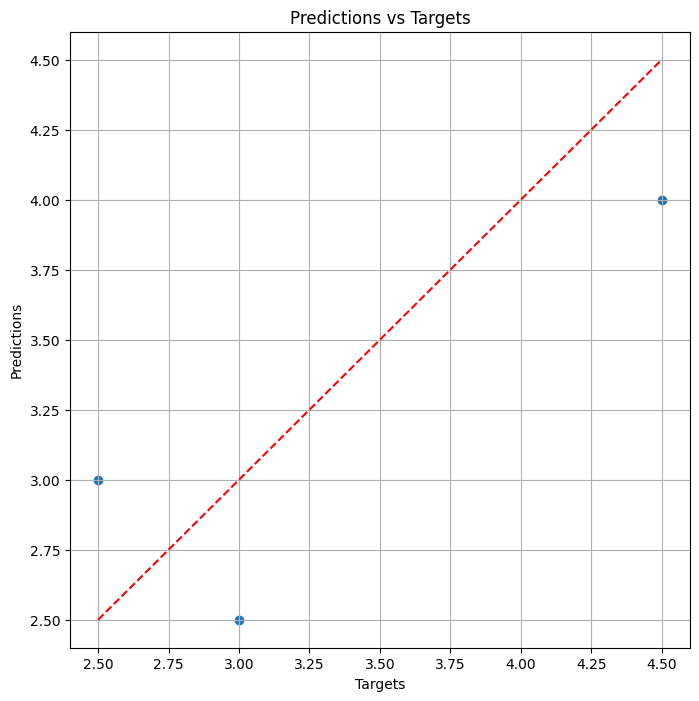

In [36]:
plot_predictions_vs_targets(predictions, targets)
